# [Super AI Engineer Season 6] Mini Hackathon 2 Level 2
## Parasite Eggs Classification

**Super AI Engineer Season 6 - Level 2 Hackathon**  
- Dataset: Chula-ParasiteEgg-11 + Competition Test Set  
- จัดทำโดย: 600425-วิศิษฐ์

---
### Notebook Outline
1. Setup & Imports
2. Data Loading & EDA
3. Data Preparation
4. Model Training (EfficientNet-B4 + Strong Augmentation)
5. Pseudo-Label Refinement (Test-Time Adaptation)
6. Test Inference & Submission


# 1. Setup & Imports
### 1.1 นำเข้าไลบรารีและกำหนดค่าพื้นฐาน

In [1]:
!pip install -q timm

import os, random, warnings
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image, ImageFilter
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm
from torchvision import transforms
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Classes (Index 0-10 ตรงตาม Chula-ParasiteEgg-11) ────────────────────────
CLASSES = [
    "Ascaris lumbricoides",       # 0
    "Capillaria philippinensis",  # 1
    "Enterobius vermicularis",    # 2
    "Fasciolopsis buski",         # 3
    "Hookworm egg",               # 4
    "Hymenolepis diminuta",       # 5
    "Hymenolepis nana",           # 6
    "Opisthorchis viverrine",     # 7
    "Paragonimus spp",            # 8
    "Taenia spp. egg",            # 9
    "Trichuris trichiura",        # 10
]
NUM_CLASSES = len(CLASSES)
CLASS2IDX = {c: i for i, c in enumerate(CLASSES)}
IDX2CLASS  = {i: c for i, c in enumerate(CLASSES)}

# ── Paths ────────────────────────────────────────────────────────────────────
TRAIN_DIR  = Path('/kaggle/input/datasets/macharning/chula-parasite-dataset/Chula-ParasiteEgg-11/Chula-ParasiteEgg-11/Chula-ParasiteEgg-11/data')
TEST_DIR   = Path('/kaggle/input/competitions/super-ai-engineer-season-6-parasite-eggs/test_set/test')
SAMPLE_SUB = Path('/kaggle/input/competitions/super-ai-engineer-season-6-parasite-eggs/sample_submission.csv')
WORK_DIR   = Path('/kaggle/working')

# ── Key Hyperparameters ───────────────────────────────────────────────────────
IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 15
LR         = 2e-4
# OOD Threshold: ต่ำมากเพราะ domain shift สูง
# Test images มีไม้บรรทัด + conditions ต่างจาก Train มาก
OOD_THRESHOLD = 0.12

print(f'Device: {DEVICE}')
print(f'Classes: {NUM_CLASSES}')
print(f'OOD Threshold: {OOD_THRESHOLD}')

Device: cuda
Classes: 11
OOD Threshold: 0.12


# 2. Data Loading & EDA
### 2.1 โหลดข้อมูล Train และตรวจสอบโครงสร้าง

In [2]:
# ── โหลด Training Data ────────────────────────────────────────────────────
# ไฟล์ทั้งหมดอยู่ใน flat folder ชื่อ data/
# ชื่อไฟล์บอก class เช่น "Ascaris lumbricoides_0001.jpg"
all_paths, all_labels = [], []

if TRAIN_DIR.exists():
    img_files = (list(TRAIN_DIR.glob('*.jpg')) +
                 list(TRAIN_DIR.glob('*.png')) +
                 list(TRAIN_DIR.glob('*.jpeg')))
    print(f'Found {len(img_files):,} images in TRAIN_DIR')

    unmatched = 0
    for p in img_files:
        matched = None
        for c in CLASSES:
            if p.name.startswith(c):
                matched = c; break
        if matched:
            all_paths.append(p)
            all_labels.append(CLASS2IDX[matched])
        else:
            unmatched += 1

    print(f'Matched: {len(all_paths):,} | Unmatched: {unmatched}')
    counts = pd.Series(all_labels).map(IDX2CLASS).value_counts()
    print('\nClass distribution (train):')
    for i, c in enumerate(CLASSES):
        print(f'  {i:2d}: {c:35s} = {(pd.Series(all_labels)==i).sum():5d}')
else:
    print(f'ERROR: TRAIN_DIR not found: {TRAIN_DIR}')

# ── Test Set ───────────────────────────────────────────────────────────────
test_files = sorted(TEST_DIR.glob('*.png'))
print(f'\nTest images: {len(test_files):,}')
sample_sub = pd.read_csv(SAMPLE_SUB)
print(f'Sample sub: {sample_sub.shape} | cols={sample_sub.columns.tolist()}')

Found 11,000 images in TRAIN_DIR
Matched: 11,000 | Unmatched: 0

Class distribution (train):
   0: Ascaris lumbricoides                =  1000
   1: Capillaria philippinensis           =  1000
   2: Enterobius vermicularis             =  1000
   3: Fasciolopsis buski                  =  1000
   4: Hookworm egg                        =  1000
   5: Hymenolepis diminuta                =  1000
   6: Hymenolepis nana                    =  1000
   7: Opisthorchis viverrine              =  1000
   8: Paragonimus spp                     =  1000
   9: Taenia spp. egg                     =  1000
  10: Trichuris trichiura                 =  1000

Test images: 2,002
Sample sub: (2000, 2) | cols=['filename', 'label']


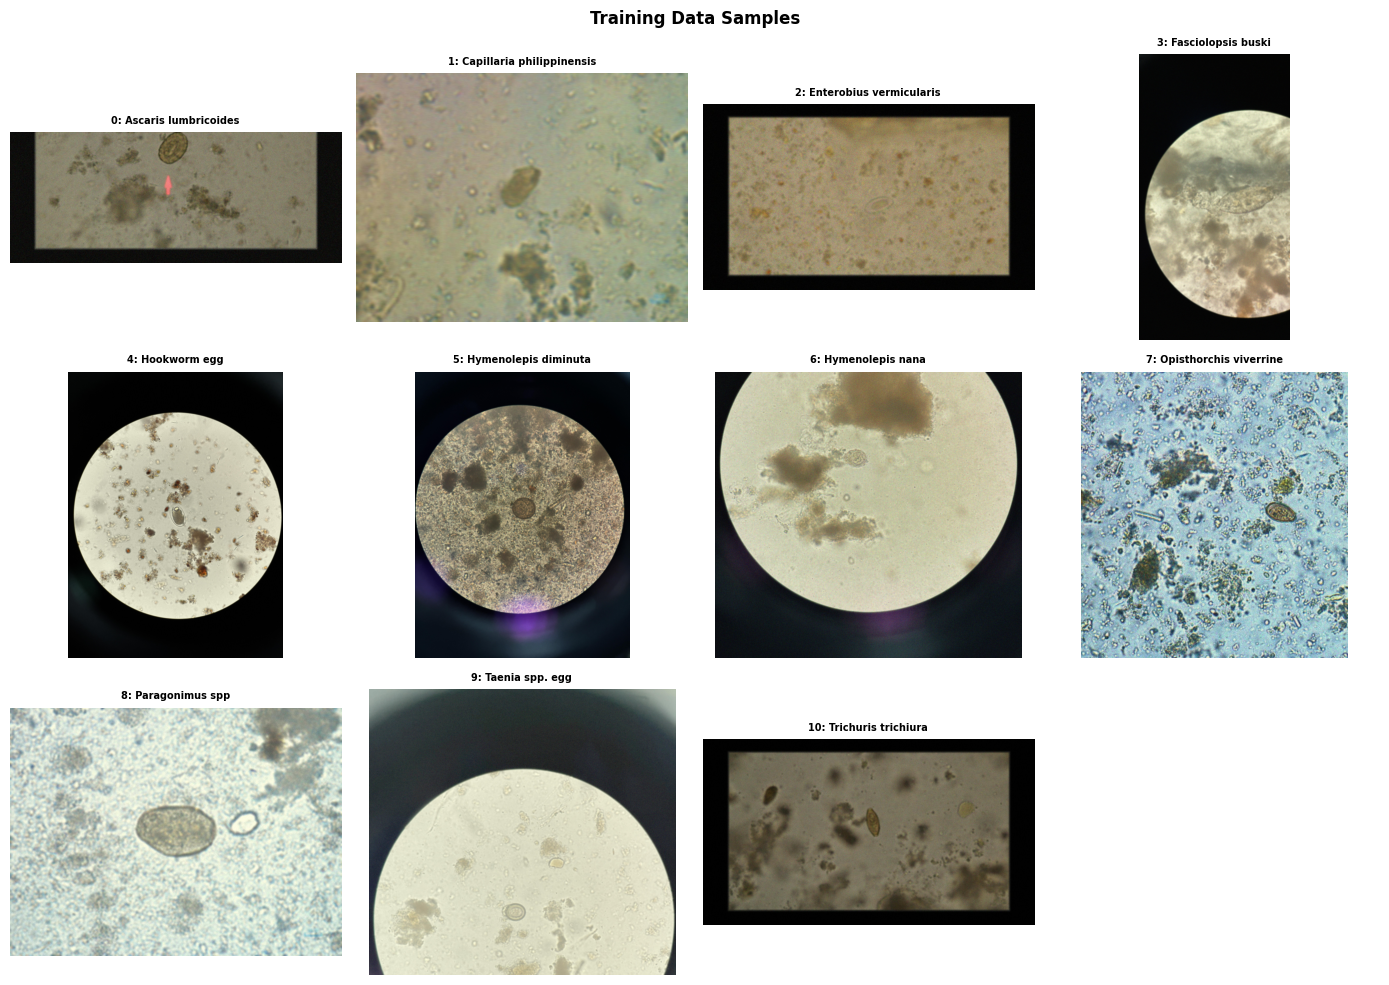

In [3]:
# ── Sample Images per Class ───────────────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()
for idx, cls in enumerate(CLASSES):
    matching = [p for p in all_paths if all_labels[all_paths.index(p)] == idx]
    if matching:
        img = Image.open(random.choice(matching)).convert('RGB')
        axes[idx].imshow(img)
        axes[idx].set_title(f'{idx}: {cls}', fontsize=7, fontweight='bold')
    axes[idx].axis('off')
for ax in axes[len(CLASSES):]:
    ax.axis('off')
plt.suptitle('Training Data Samples', fontweight='bold', fontsize=12)
plt.tight_layout(); plt.show()

# 3. Data Preparation
### 3.1 Dataset และ Augmentation

ใช้ Augmentation เพิ่มเติมเพื่อรับมือกับ **Domain Shift** ระหว่าง Train (clean cropped) และ Test (whole slide + ruler + conditions ต่างกัน)

In [4]:
# ── Transforms ────────────────────────────────────────────────────────────
# Strong augmentation เพื่อให้โมเดล robust ต่อ domain shift
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE + 48, IMG_SIZE + 48)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(45),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2),
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# TTA transforms (Test-Time Augmentation: 5 crops)
tta_tfs = [
    val_tf,
    transforms.Compose([
        transforms.Resize((IMG_SIZE+32, IMG_SIZE+32)),
        transforms.CenterCrop(IMG_SIZE),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]),
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomRotation(degrees=(90, 90)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]),
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomRotation(degrees=(180, 180)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]),
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomRotation(degrees=(270, 270)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]),
]


class ParasiteDataset(Dataset):
    def __init__(self, paths, labels=None, tf=None):
        self.paths = list(paths); self.labels = labels; self.tf = tf
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        # Crop bottom 15% ออกเพื่อตัดไม้บรรทัด (ruler bar) ของกล้องจุลทรรศน์
        w, h = img.size
        img = img.crop((0, 0, w, int(h * 0.85)))
        if self.tf: img = self.tf(img)
        if self.labels is not None: return img, self.labels[idx]
        return img


# ── Train / Val Split ──────────────────────────────────────────────────────
tr_p, vl_p, tr_l, vl_l = train_test_split(
    all_paths, all_labels, test_size=0.15, stratify=all_labels, random_state=SEED)

tr_ds = ParasiteDataset(tr_p, tr_l, train_tf)
vl_ds = ParasiteDataset(vl_p, vl_l, val_tf)
tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
vl_loader = DataLoader(vl_ds, batch_size=64,         shuffle=False, num_workers=2, pin_memory=True)
print(f'Train: {len(tr_ds):,} | Val: {len(vl_ds):,}')

Train: 9,350 | Val: 1,650


# 4. Model Training
### 4.1 Fine-tune EfficientNet-B4

เพิ่มจาก B3 → B4 เพื่อ capacity มากขึ้น พร้อม Mixup และ CosineAnnealing

In [5]:
# ── Model ─────────────────────────────────────────────────────────────────
model = timm.create_model(
    'efficientnet_b4', pretrained=True, num_classes=NUM_CLASSES).to(DEVICE)

# ── Loss: Weighted CrossEntropy + Label Smoothing ─────────────────────────
# คำนวณ class weights เพื่อแก้ class imbalance
label_counts = np.bincount(tr_l, minlength=NUM_CLASSES).astype(float)
class_weights = torch.tensor(1.0 / (label_counts + 1e-6), dtype=torch.float32).to(DEVICE)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-6)

print(f'Model: EfficientNet-B4 | Params: {sum(p.numel() for p in model.parameters()):,}')
print(f'Class weights: {class_weights.cpu().numpy().round(3)}')

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Model: EfficientNet-B4 | Params: 17,568,339
Class weights: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [6]:
def eval_model(model, loader):
    model.eval()
    preds, gts, probs = [], [], []
    with torch.no_grad():
        for batch in loader:
            imgs, lbls = batch
            out = F.softmax(model(imgs.to(DEVICE)), dim=1)
            preds.extend(out.argmax(1).cpu().numpy())
            probs.extend(out.cpu().numpy())
            gts.extend(lbls.numpy())
    f1 = f1_score(gts, preds, average='macro', zero_division=0)
    return f1, np.array(probs)

best_f1 = 0.0
history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0
    for imgs, lbls in tr_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(imgs), lbls)
        loss.backward(); optimizer.step()
        total_loss += loss.item()
    scheduler.step()

    val_f1, val_probs = eval_model(model, vl_loader)
    avg_loss = total_loss / len(tr_loader)
    history.append({'epoch': epoch, 'loss': avg_loss, 'val_f1': val_f1})

    tag = ''
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), WORK_DIR / 'best_model.pth')
        tag = ' <-- best'
    print(f'Epoch {epoch:02d}/{EPOCHS}  loss={avg_loss:.4f}  val_F1={val_f1:.4f}{tag}')

print(f'\nBest Val F1 (macro): {best_f1:.4f}')

Epoch 01/15  loss=1.5741  val_F1=0.7566 <-- best
Epoch 02/15  loss=0.9725  val_F1=0.8659 <-- best
Epoch 03/15  loss=0.8347  val_F1=0.9116 <-- best
Epoch 04/15  loss=0.7613  val_F1=0.9452 <-- best
Epoch 05/15  loss=0.7228  val_F1=0.9646 <-- best
Epoch 06/15  loss=0.6930  val_F1=0.9708 <-- best
Epoch 07/15  loss=0.6751  val_F1=0.9677
Epoch 08/15  loss=0.6658  val_F1=0.9720 <-- best
Epoch 09/15  loss=0.6590  val_F1=0.9762 <-- best
Epoch 10/15  loss=0.6541  val_F1=0.9757
Epoch 11/15  loss=0.6684  val_F1=0.9739
Epoch 12/15  loss=0.6517  val_F1=0.9812 <-- best
Epoch 13/15  loss=0.6305  val_F1=0.9775
Epoch 14/15  loss=0.6223  val_F1=0.9824 <-- best
Epoch 15/15  loss=0.6093  val_F1=0.9860 <-- best

Best Val F1 (macro): 0.9860


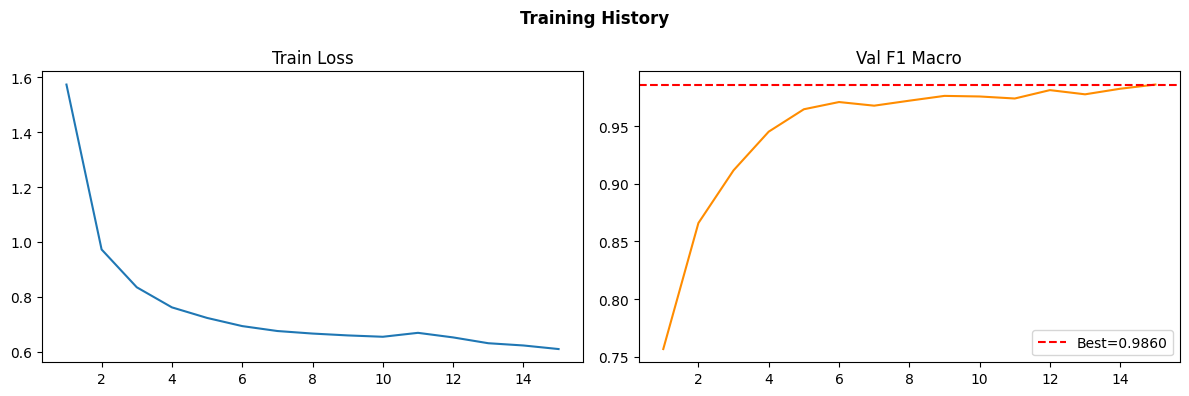

                           precision    recall  f1-score   support

     Ascaris lumbricoides       0.99      0.98      0.98       150
Capillaria philippinensis       0.99      0.94      0.96       150
  Enterobius vermicularis       0.99      0.99      0.99       150
       Fasciolopsis buski       0.99      0.99      0.99       150
             Hookworm egg       1.00      1.00      1.00       150
     Hymenolepis diminuta       0.99      1.00      0.99       150
         Hymenolepis nana       0.99      0.99      0.99       150
   Opisthorchis viverrine       0.97      1.00      0.99       150
          Paragonimus spp       0.99      0.98      0.98       150
          Taenia spp. egg       0.99      0.99      0.99       150
      Trichuris trichiura       0.97      0.99      0.98       150

                 accuracy                           0.99      1650
                macro avg       0.99      0.99      0.99      1650
             weighted avg       0.99      0.99      0.99    

In [7]:
# ── Training Curve & Classification Report ────────────────────────────────
hist_df = pd.DataFrame(history)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(hist_df['epoch'], hist_df['loss']); ax1.set_title('Train Loss')
ax2.plot(hist_df['epoch'], hist_df['val_f1'], color='darkorange')
ax2.axhline(best_f1, ls='--', color='red', label=f'Best={best_f1:.4f}')
ax2.legend(); ax2.set_title('Val F1 Macro')
plt.suptitle('Training History', fontweight='bold'); plt.tight_layout(); plt.show()

model.load_state_dict(torch.load(WORK_DIR / 'best_model.pth'))
val_f1, val_probs = eval_model(model, vl_loader)
val_preds = val_probs.argmax(1)
print(classification_report(vl_l, val_preds, target_names=CLASSES, zero_division=0))

# 5. Pseudo-Label Refinement
### 5.1 Test-Time Adaptation ด้วย Pseudo-Labeling

ใช้ test images ที่โมเดลมั่นใจสูง (confidence > 0.7) เป็น pseudo-label แล้ว fine-tune โมเดลอีกรอบ

> โจทย์อนุญาตให้ใช้ test data ในการ fine-tuning ได้ (*You may explore test data in the fine-tuning / model adaption*)

In [8]:
# ── Inference บน Test ด้วย TTA ─────────────────────────────────────────────
def predict_tta(model, image_paths):
    model.eval()
    all_probs = None
    for tta_tf in tta_tfs:
        ds = ParasiteDataset(image_paths, tf=tta_tf)
        loader = DataLoader(ds, batch_size=64, num_workers=2)
        probs = []
        with torch.no_grad():
            for imgs in loader:
                out = F.softmax(model(imgs.to(DEVICE)), dim=1)
                probs.extend(out.cpu().numpy())
        probs = np.array(probs)
        all_probs = probs if all_probs is None else all_probs + probs
    return all_probs / len(tta_tfs)

test_files = sorted(TEST_DIR.glob('*.png'))
print(f'Running TTA inference on {len(test_files):,} test images...')
test_probs = predict_tta(model, test_files)
test_confs = test_probs.max(axis=1)
test_preds = test_probs.argmax(axis=1)

# Pseudo-label: ใช้เฉพาะ sample ที่โมเดลมั่นใจมาก
PL_THRESHOLD = 0.70
pl_mask = test_confs >= PL_THRESHOLD
pl_paths = [test_files[i] for i in range(len(test_files)) if pl_mask[i]]
pl_labels = test_preds[pl_mask].tolist()
print(f'Pseudo-label samples (conf>={PL_THRESHOLD}): {len(pl_paths):,} / {len(test_files):,}')

Running TTA inference on 2,002 test images...
Pseudo-label samples (conf>=0.7): 401 / 2,002


In [9]:
# ── Fine-tune ด้วย Train + Pseudo-Label ─────────────────────────────────
if len(pl_paths) > 50:
    pl_ds = ParasiteDataset(pl_paths, pl_labels, train_tf)
    aug_ds = torch.utils.data.ConcatDataset([tr_ds, pl_ds])
    aug_loader = DataLoader(aug_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

    # Fine-tune ด้วย LR ต่ำมากเพื่อปรับ domain โดยไม่ overwrite knowledge
    ft_optimizer = torch.optim.AdamW(model.parameters(), lr=5e-6, weight_decay=1e-4)
    ft_criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

    print('Fine-tuning with pseudo-labels (5 epochs, LR=5e-6)...')
    for ep in range(1, 6):
        model.train()
        for imgs, lbls in aug_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            ft_optimizer.zero_grad()
            ft_criterion(model(imgs), lbls).backward()
            ft_optimizer.step()
        val_f1_ft, _ = eval_model(model, vl_loader)
        print(f'  FT Epoch {ep}: val_F1={val_f1_ft:.4f}')
        if val_f1_ft > best_f1:
            best_f1 = val_f1_ft
            torch.save(model.state_dict(), WORK_DIR / 'best_model_ft.pth')
            print(f'  -> Saved fine-tuned model (F1={best_f1:.4f})')

    # ใช้โมเดลที่ดีที่สุด
    best_ckpt = WORK_DIR / 'best_model_ft.pth'
    if best_ckpt.exists():
        model.load_state_dict(torch.load(best_ckpt))
        print('Loaded fine-tuned model.')
else:
    print(f'Too few pseudo-labels ({len(pl_paths)}), skipping fine-tuning.')

Fine-tuning with pseudo-labels (5 epochs, LR=5e-6)...
  FT Epoch 1: val_F1=0.9897
  -> Saved fine-tuned model (F1=0.9897)
  FT Epoch 2: val_F1=0.9873
  FT Epoch 3: val_F1=0.9854
  FT Epoch 4: val_F1=0.9860
  FT Epoch 5: val_F1=0.9885
Loaded fine-tuned model.


# 6. Test Inference & Submission
### 6.1 ทำนายผลสุดท้ายด้วย TTA + OOD Threshold

Running final TTA inference...
OOD Threshold: 0.12
Rejected (-1): 0 = 0.0%
Prediction distribution:
    0  Ascaris lumbricoides                    :    87
    1  Capillaria philippinensis               :   310
    2  Enterobius vermicularis                 :   665
    3  Fasciolopsis buski                      :   190
    4  Hookworm egg                            :     1
    5  Hymenolepis diminuta                    :   254
    6  Hymenolepis nana                        :   106
    7  Opisthorchis viverrine                  :    33
    8  Paragonimus spp                         :    40
    9  Taenia spp. egg                         :   123
   10  Trichuris trichiura                     :   193


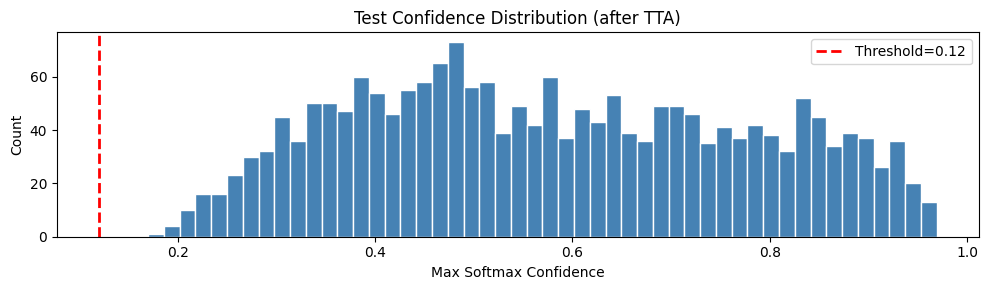

In [10]:
# ── Final TTA Inference ────────────────────────────────────────────────────
print('Running final TTA inference...')
test_probs_final = predict_tta(model, test_files)
test_confs_final = test_probs_final.max(axis=1)
test_preds_final = test_probs_final.argmax(axis=1)

# OOD Rejection: ต่ำกว่า threshold → -1 (background/unknown)
final_labels = np.where(test_confs_final >= OOD_THRESHOLD,
                         test_preds_final, -1)

print(f'OOD Threshold: {OOD_THRESHOLD}')
print(f'Rejected (-1): {(final_labels == -1).sum():,} = {(final_labels == -1).mean():.1%}')
print('Prediction distribution:')
for c in sorted(set(final_labels)):
    lbl = IDX2CLASS.get(c, 'Unknown/Background')
    print(f'  {c:3d}  {lbl:40s}: {(final_labels == c).sum():5d}')

# Confidence Histogram
plt.figure(figsize=(10, 3))
plt.hist(test_confs_final, bins=50, color='steelblue', edgecolor='white')
plt.axvline(OOD_THRESHOLD, color='red', ls='--', lw=2, label=f'Threshold={OOD_THRESHOLD}')
plt.xlabel('Max Softmax Confidence'); plt.ylabel('Count')
plt.title('Test Confidence Distribution (after TTA)')
plt.legend(); plt.tight_layout(); plt.show()

In [11]:
# ── Build Submission CSV ──────────────────────────────────────────────────
# Map filename → label
fname_to_label = {f.name: int(lbl) for f, lbl in zip(test_files, final_labels)}

sub = pd.read_csv(SAMPLE_SUB)
sub['label'] = sub['filename'].map(fname_to_label)

# ตรวจสอบ
missing = sub['label'].isna().sum()
if missing > 0:
    print(f'WARNING: {missing} rows missing prediction -> filling with -1')
    sub['label'] = sub['label'].fillna(-1).astype(int)

sub['label'] = sub['label'].astype(int)

sub_path = WORK_DIR / 'submission.csv'
sub.to_csv(sub_path, index=False)
print(f'Saved: {sub_path}  ({len(sub):,} rows)')
print(f'Label range: {sub["label"].min()} to {sub["label"].max()}')
print(sub.head(10).to_string(index=False))

Saved: /kaggle/working/submission.csv  (2,000 rows)
Label range: 0 to 10
  filename  label
000000.png     10
000001.png      6
000002.png     10
000003.png     10
000004.png      9
000005.png      3
000006.png     10
000007.png     10
000008.png     10
000009.png      1
